# 🔬 RAG System Advanced Analytics

Ingest `detailed_eval_results.json` and generate:
- **Document-Level Metrics** — Top/Bottom 5 sources by faithfulness & context utilization
- **Multilingual Performance** — Grouped bar chart across all tested languages
- **CoT Analysis** — Correlation between reasoning length and answer relevancy


In [13]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from scipy import stats

# ── Style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 130,
})
PALETTE = ['#4db8b0', '#f4845f', '#9b7fca', '#f7c59f', '#4a90d9', '#e8a598', '#7bc67e']
print('Libraries loaded ✅')

Libraries loaded ✅


## 1. Load Data

In [14]:
RESULTS_PATH = Path('../reports/detailed_eval_results.json')
DOC_PERF_PATH = Path('../reports/doc_performance.json')

assert RESULTS_PATH.exists(), f'File not found: {RESULTS_PATH}. Run main.py first.'

with open(RESULTS_PATH, 'r', encoding='utf-8') as f:
    payload = json.load(f)

meta    = payload.get('metadata', {})
records = payload.get('results', [])

print(f"Model    : {meta.get('model', 'unknown')}")
print(f"Timestamp: {meta.get('timestamp', 'unknown')}")
print(f"Records  : {len(records)}")

df_all = pd.DataFrame(records)
df_all['reasoning_length'] = df_all['reasoning'].fillna('').apply(len)

# Answered-only subset (non-negative, has Ragas scores)
df = df_all[df_all['is_negative'] == False].copy()
df = df.dropna(subset=['faithfulness', 'answer_relevancy', 'context_utilization'])

print(f"Answered : {len(df)} / {len(df_all)}")
df[['question', 'language', 'faithfulness', 'answer_relevancy', 'context_utilization', 'reasoning_length']].head()

Model    : llama3.1:8b
Timestamp: 20260503_010618
Records  : 50
Answered : 34 / 50


,question,language,faithfulness,answer_relevancy,context_utilization,reasoning_length
1,Qu’est-ce qui cause la scarlatine chez les enf...,French,0.800000,0.530956,1.000000,635
2,Qu’est-ce que l’impétigo chez les enfants ?,French,0.833333,0.710306,1.000000,688
4,Wie wird eine Rotavirus-Infektion bei Säugling...,German,0.500000,0.671415,0.805556,406
6,What is impetigo in children?,English,1.000000,0.703453,1.000000,753
7,Quais são os sintomas da caxumba em crianças?,Portuguese,0.833333,0.514238,0.833333,508


## 2. Document-Level Metrics

We explode `retrieved_docs` so every (question, document) pair becomes one row, then join the Ragas scores.

In [15]:
# ── Explode retrieved_docs ─────────────────────────────────────────────────
doc_rows = []
for _, row in df.iterrows():
    for doc in (row['retrieved_docs'] or []):
        doc_rows.append({
            'source'              : doc.get('source', 'unknown'),
            'title'               : doc.get('title',  'unknown'),
            'relevance_score'     : doc.get('relevance_score', 0.0),
            'faithfulness'        : row['faithfulness'],
            'answer_relevancy'    : row['answer_relevancy'],
            'context_utilization' : row['context_utilization'],
        })

df_docs = pd.DataFrame(doc_rows)
print(f'Total (question × doc) rows: {len(df_docs)}')
print(f'Unique source URLs         : {df_docs["source"].nunique()}')
df_docs.head(3)

Total (question × doc) rows: 170
Unique source URLs         : 30


,source,title,relevance_score,faithfulness,answer_relevancy,context_utilization
0,https://kidshealth.org/en/parents/scarlet-feve...,Scarlet Fever | Nemours KidsHealth,0.997149,0.8,0.530956,1.0
1,https://kidshealth.org/en/parents/scarlet-feve...,Scarlet Fever | Nemours KidsHealth,0.983404,0.8,0.530956,1.0
2,https://kidshealth.org/en/parents/scarlet-feve...,Scarlet Fever | Nemours KidsHealth,0.918526,0.8,0.530956,1.0


In [16]:
# ── Aggregate per source ──────────────────────────────────────────────────
METRIC_COLS = ['faithfulness', 'context_utilization', 'answer_relevancy']

doc_agg = (
    df_docs
    .groupby(['source', 'title'])[METRIC_COLS]
    .agg(['mean', 'count'])
)
doc_agg.columns = ['_'.join(c) for c in doc_agg.columns]
doc_agg = doc_agg.reset_index()

# Use faithfulness count as appearances proxy
doc_agg.rename(columns={'faithfulness_count': 'appearances'}, inplace=True)
doc_agg.drop(columns=['context_utilization_count', 'answer_relevancy_count'], inplace=True)

# Filter to sources with ≥2 appearances for reliability
doc_agg_filtered = doc_agg[doc_agg['appearances'] >= 2].copy()
doc_agg_filtered.sort_values('faithfulness_mean', ascending=False, inplace=True)

print(f'Sources with ≥2 appearances: {len(doc_agg_filtered)}')
doc_agg_filtered.head(10)

Sources with ≥2 appearances: 25


,source,title,faithfulness_mean,appearances,context_utilization_mean,answer_relevancy_mean
6,https://kidshealth.org/en/parents/conjunctivit...,Conjunctivitis (Pinkeye) In Kids | Nemours Kid...,1.000000,15,0.851389,0.593329
22,https://kidshealth.org/en/parents/norovirus.html,Norovirus | Nemours KidsHealth,1.000000,6,0.860417,0.927977
19,https://kidshealth.org/en/parents/measles.html,Measles (Rubeola) | Nemours KidsHealth,1.000000,5,0.802222,0.676090
18,https://kidshealth.org/en/parents/measles-keep...,Measles: What You Need to Know | Nemours KidsH...,1.000000,5,0.802222,0.676090
13,https://kidshealth.org/en/parents/german-measl...,Rubella (German Measles) | Nemours KidsHealth,1.000000,5,0.901111,0.636080
0,https://kidshealth.org/en/parents/adenovirus.html,Adenovirus Infections | Nemours KidsHealth,0.984375,4,0.930208,0.871442
1,https://kidshealth.org/en/parents/bronchioliti...,Bronchiolitis | Nemours KidsHealth,0.980000,10,0.863889,0.651110
4,https://kidshealth.org/en/parents/chickenpox-s...,Chickenpox: Treatment & Care | Nemours KidsHealth,0.968750,2,1.000000,0.814908
3,https://kidshealth.org/en/parents/chicken-pox....,Chickenpox (Varicella) | Nemours KidsHealth,0.968750,4,1.000000,0.814908
5,https://kidshealth.org/en/parents/chiggers.html,"Chigger Bites: Signs, Causes & Treatment | Nem...",0.968750,2,1.000000,0.814908


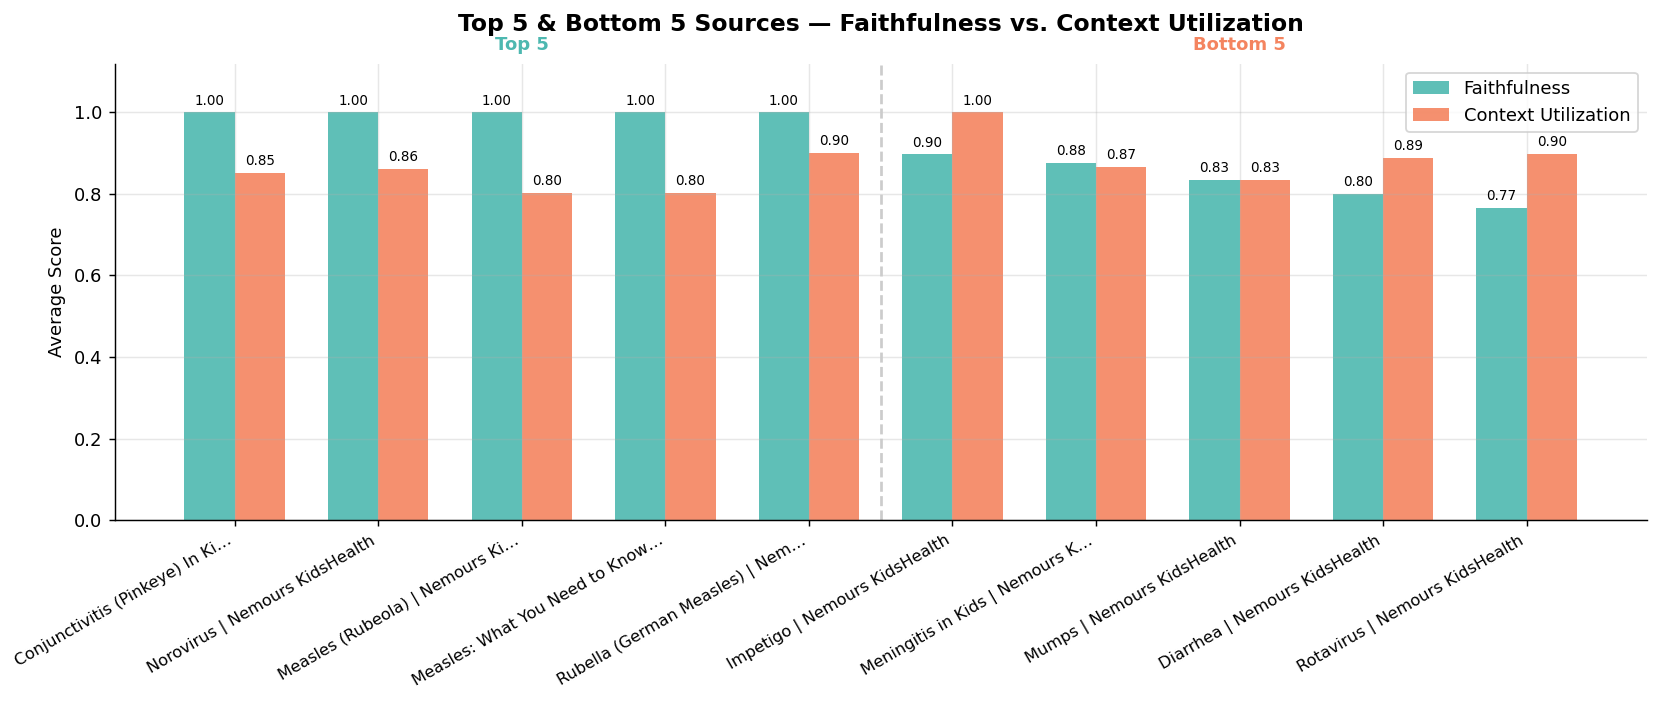

Saved → reports/doc_metrics_top_bottom5.png


In [17]:
# ── Top 5 / Bottom 5 bar chart ────────────────────────────────────────────

def short_label(title: str, url: str, max_len: int = 30) -> str:
    label = title if title and title != 'unknown' else url.split('/')[-1]
    return label[:max_len] + ('…' if len(label) > max_len else '')

top5    = doc_agg_filtered.head(5)
bottom5 = doc_agg_filtered.tail(5)
combined = pd.concat([top5, bottom5])

labels = [short_label(r['title'], r['source']) for _, r in combined.iterrows()]
x      = np.arange(len(labels))
width  = 0.35

fig, ax = plt.subplots(figsize=(13, 5.5))

bars1 = ax.bar(x - width/2, combined['faithfulness_mean'],    width, label='Faithfulness',        color=PALETTE[0], alpha=.9)
bars2 = ax.bar(x + width/2, combined['context_utilization_mean'], width, label='Context Utilization', color=PALETTE[1], alpha=.9)

# Separator line between top5 and bottom5
ax.axvline(x=4.5, color='#ccc', linewidth=1.5, linestyle='--')
ax.text(2.0, 1.03, 'Top 5', ha='center', fontsize=10, color='#4db8b0', fontweight='bold',
        transform=ax.get_xaxis_transform())
ax.text(7.0, 1.03, 'Bottom 5', ha='center', fontsize=10, color='#f4845f', fontweight='bold',
        transform=ax.get_xaxis_transform())

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Average Score')
ax.set_ylim(0, 1.12)
ax.set_title('Top 5 & Bottom 5 Sources — Faithfulness vs. Context Utilization', fontsize=13, fontweight='bold', pad=18)
ax.legend()

# Value labels
for bar in [*bars1, *bars2]:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + .012, f'{h:.2f}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.savefig('../reports/doc_metrics_top_bottom5.png', bbox_inches='tight')
plt.show()
print('Saved → reports/doc_metrics_top_bottom5.png')

## 3. Multilingual Performance Analytics

In [18]:
# ── Formula: per-language averages ────────────────────────────────────────
#
#   avg_metric[lang] = mean( metric_score[i]  for i where language[i] == lang )
#
lang_agg = (
    df
    .groupby('language')[['faithfulness', 'answer_relevancy', 'context_utilization']]
    .agg(['mean', 'std', 'count'])
)
lang_agg.columns = ['_'.join(c) for c in lang_agg.columns]
lang_agg = lang_agg.reset_index()

# Compute delta vs English (if present)
if 'English' in lang_agg['language'].values:
    eng = lang_agg[lang_agg['language'] == 'English'].iloc[0]
    for m in ['faithfulness', 'answer_relevancy', 'context_utilization']:
        lang_agg[f'{m}_delta_vs_en'] = lang_agg[f'{m}_mean'] - eng[f'{m}_mean']

lang_agg.sort_values('faithfulness_mean', ascending=False, inplace=True)
lang_agg

,language,faithfulness_mean,faithfulness_std,faithfulness_count,answer_relevancy_mean,answer_relevancy_std,answer_relevancy_count,context_utilization_mean,context_utilization_std,context_utilization_count,faithfulness_delta_vs_en,answer_relevancy_delta_vs_en,context_utilization_delta_vs_en
0,English,1.000000,0.000000,7,0.836032,0.093856,7,0.898214,0.112316,7,0.000000,0.000000,0.000000
4,Spanish,0.938889,0.095258,6,0.713617,0.113212,6,0.829398,0.173526,6,-0.061111,-0.122415,-0.068816
3,Portuguese,0.928214,0.081120,10,0.664847,0.165529,10,0.903611,0.091604,10,-0.071786,-0.171184,0.005397
1,French,0.874167,0.090158,5,0.616573,0.097106,5,0.878889,0.170891,5,-0.125833,-0.219459,-0.019325
2,German,0.850000,0.197484,6,0.705226,0.150550,6,0.881481,0.098799,6,-0.150000,-0.130805,-0.016733


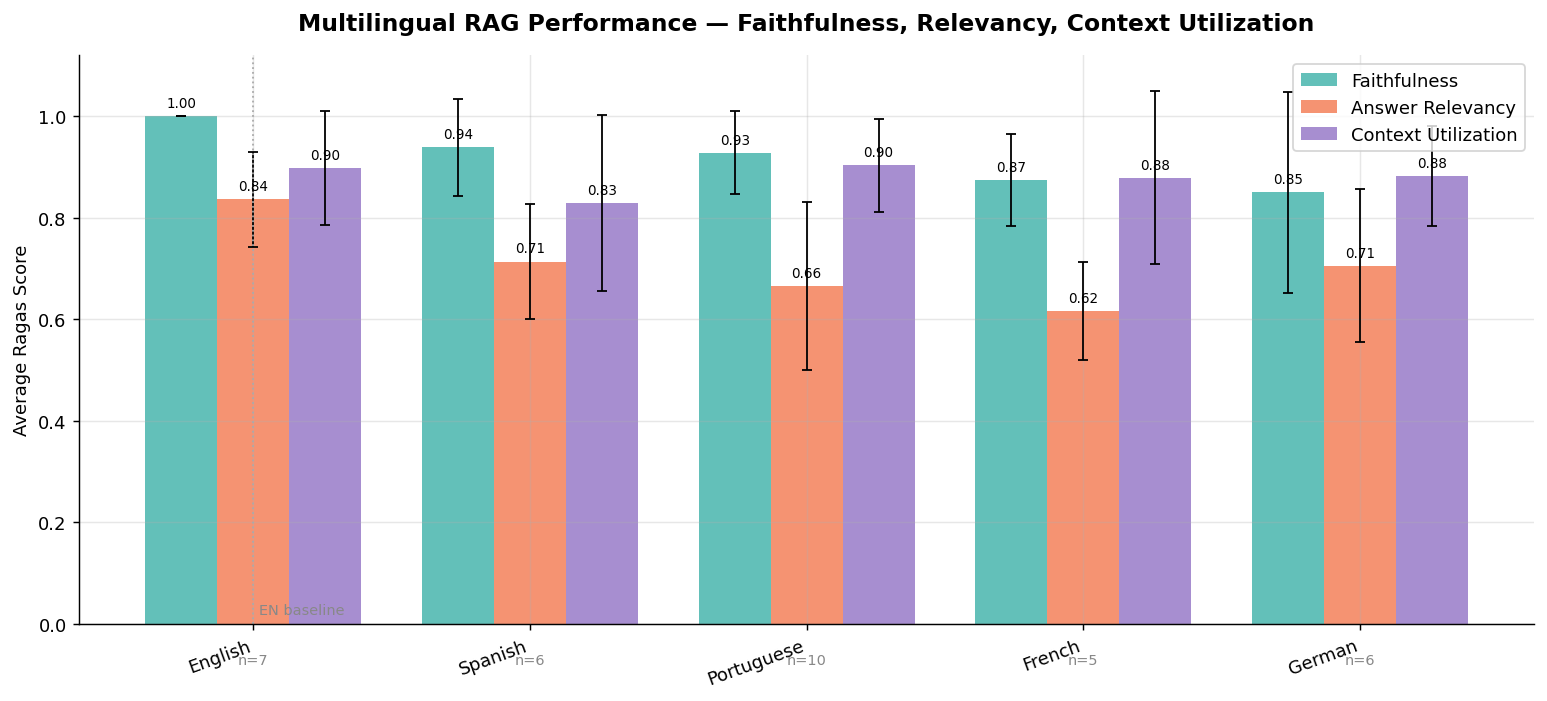

Saved → reports/multilingual_performance.png


In [19]:
# ── Grouped bar chart ─────────────────────────────────────────────────────
languages = lang_agg['language'].tolist()
x = np.arange(len(languages))
width = 0.26

fig, ax = plt.subplots(figsize=(12, 5.5))

metrics = [
    ('faithfulness_mean',        'Faithfulness',        PALETTE[0]),
    ('answer_relevancy_mean',    'Answer Relevancy',    PALETTE[1]),
    ('context_utilization_mean', 'Context Utilization', PALETTE[2]),
]

offsets = [-width, 0, width]
for (col, label, color), offset in zip(metrics, offsets):
    vals  = lang_agg[col].values
    stds  = lang_agg[col.replace('mean', 'std')].fillna(0).values
    bars  = ax.bar(x + offset, vals, width, label=label, color=color, alpha=.88, yerr=stds, capsize=3, error_kw={'linewidth':1})
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + .012, f'{h:.2f}',
                ha='center', va='bottom', fontsize=7.5)

# Highlight English baseline
if 'English' in languages:
    en_idx = languages.index('English')
    ax.axvline(x=en_idx, color='#aaa', linewidth=1, linestyle=':')
    ax.text(en_idx + 0.02, 0.02, 'EN baseline', fontsize=8, color='#888')

ax.set_xticks(x)
ax.set_xticklabels(languages, rotation=20, ha='right', fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Average Ragas Score')
ax.set_title('Multilingual RAG Performance — Faithfulness, Relevancy, Context Utilization', fontsize=13, fontweight='bold', pad=14)
ax.legend(loc='upper right')

# Sample-count annotations below x-axis
counts = lang_agg['faithfulness_count'].values
for i, cnt in enumerate(counts):
    ax.text(i, -0.07, f'n={int(cnt)}', ha='center', fontsize=8, color='#888', transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.savefig('../reports/multilingual_performance.png', bbox_inches='tight')
plt.show()
print('Saved → reports/multilingual_performance.png')

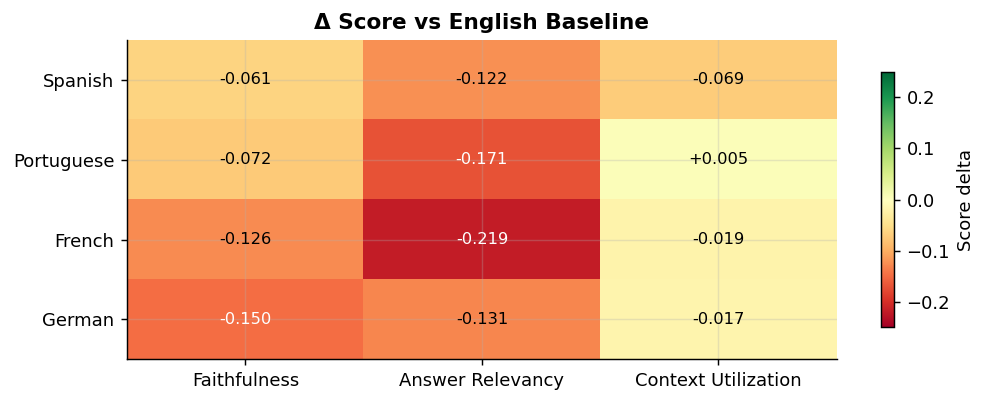

Saved → reports/multilingual_delta_heatmap.png


In [20]:
# ── Delta vs English heat-map ─────────────────────────────────────────────
delta_cols = [c for c in lang_agg.columns if 'delta_vs_en' in c]
if delta_cols:
    delta_df = lang_agg[lang_agg['language'] != 'English'].set_index('language')[delta_cols]
    delta_df.columns = [c.replace('_delta_vs_en','').replace('_',' ').title() for c in delta_df.columns]

    fig, ax = plt.subplots(figsize=(8, max(3, len(delta_df)*0.55 + 1)))
    im = ax.imshow(delta_df.values.astype(float), cmap='RdYlGn', vmin=-.25, vmax=.25, aspect='auto')

    ax.set_xticks(range(len(delta_df.columns)))
    ax.set_xticklabels(delta_df.columns, fontsize=10)
    ax.set_yticks(range(len(delta_df)))
    ax.set_yticklabels(delta_df.index, fontsize=10)
    ax.set_title('Δ Score vs English Baseline', fontsize=12, fontweight='bold')

    for i in range(len(delta_df)):
        for j in range(len(delta_df.columns)):
            val = delta_df.values[i, j]
            ax.text(j, i, f'{val:+.3f}', ha='center', va='center', fontsize=9,
                    color='black' if abs(val) < 0.15 else 'white')

    plt.colorbar(im, ax=ax, shrink=.8, label='Score delta')
    plt.tight_layout()
    plt.savefig('../reports/multilingual_delta_heatmap.png', bbox_inches='tight')
    plt.show()
    print('Saved → reports/multilingual_delta_heatmap.png')
else:
    print('No English baseline found — skipping delta heatmap.')

## 4. Chain-of-Thought Analysis

In [21]:
# ── Descriptive stats ─────────────────────────────────────────────────────
print('Reasoning length stats (chars):')
print(df['reasoning_length'].describe().round(1))
print()

# Pearson & Spearman correlation  
# Formula:  r = Σ[(xᵢ - x̄)(yᵢ - ȳ)] / sqrt[Σ(xᵢ-x̄)² · Σ(yᵢ-ȳ)²]
mask = df['reasoning_length'] > 0
x_arr = df.loc[mask, 'reasoning_length'].values
y_arr = df.loc[mask, 'answer_relevancy'].values

if len(x_arr) >= 5:
    pearson_r, pearson_p  = stats.pearsonr(x_arr, y_arr)
    spearman_r, spearman_p = stats.spearmanr(x_arr, y_arr)
    print(f'Pearson  r = {pearson_r:+.4f}  (p={pearson_p:.4f})')
    print(f'Spearman r = {spearman_r:+.4f}  (p={spearman_p:.4f})')
    sig = lambda p: '✅ significant (p<0.05)' if p < 0.05 else '❌ not significant'
    print(f'Pearson:  {sig(pearson_p)}')
    print(f'Spearman: {sig(spearman_p)}')
else:
    print('Not enough data points for correlation (need ≥5).')
    pearson_r = spearman_r = None

Reasoning length stats (chars):
count     34.0
mean     556.4
std      158.5
min       57.0
25%      467.2
50%      595.0
75%      623.0
max      886.0
Name: reasoning_length, dtype: float64

Pearson  r = +0.0393  (p=0.8254)
Spearman r = +0.0674  (p=0.7049)
Pearson:  ❌ not significant
Spearman: ❌ not significant


/tmp/ipykernel_39307/3622186587.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(lang_groups, labels=languages, patch_artist=True, notch=False)


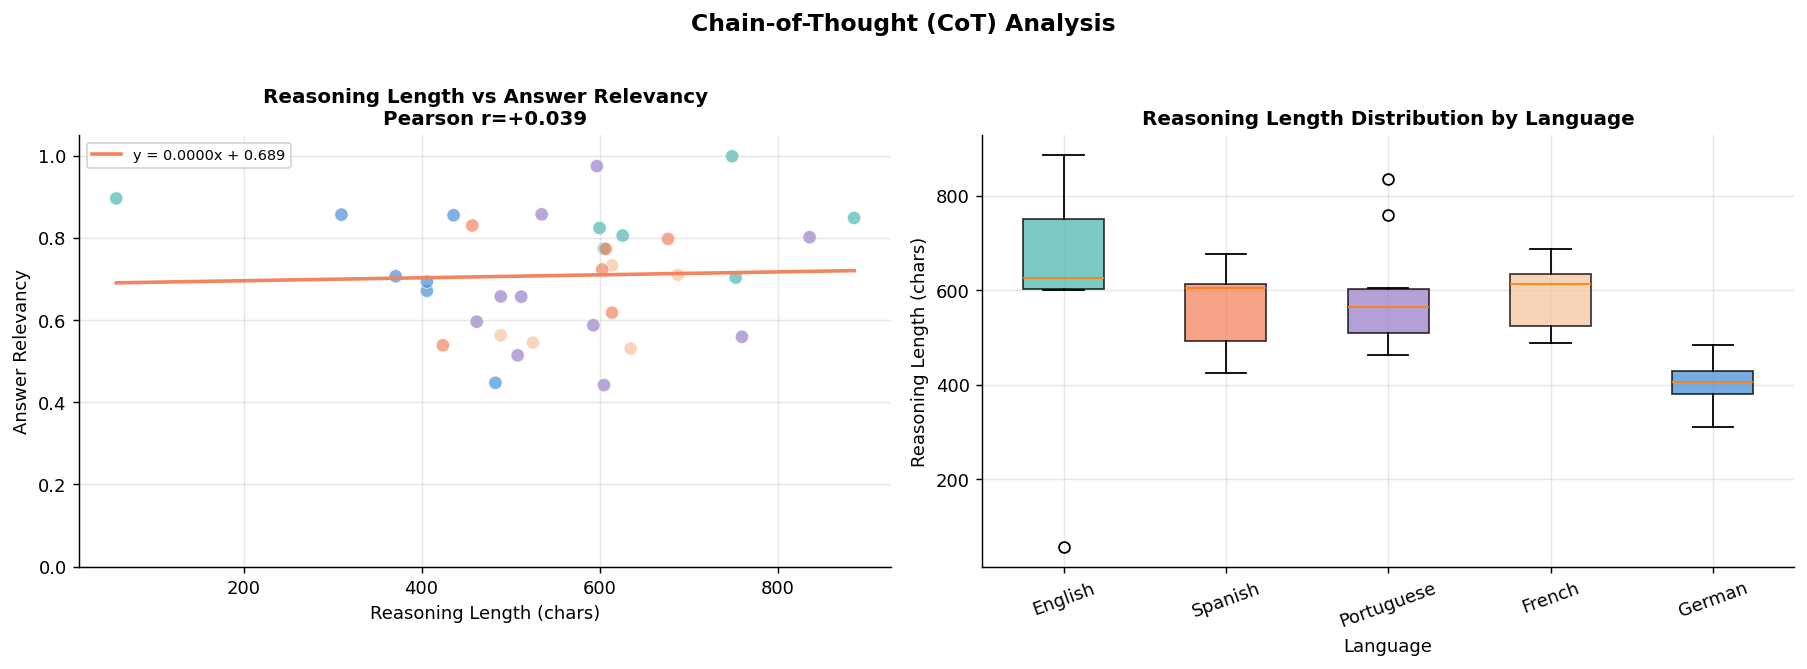

Saved → reports/cot_analysis.png


In [22]:
# ── Scatter + regression line ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Left: reasoning length vs answer_relevancy —
ax = axes[0]
scatter_colors = [PALETTE[languages.index(lang) % len(PALETTE)]
                  if lang in languages else '#ccc'
                  for lang in df.loc[mask, 'language']]

ax.scatter(x_arr, y_arr, c=scatter_colors, alpha=.7, s=55, edgecolors='white', linewidth=.5)

if pearson_r is not None:
    m, b = np.polyfit(x_arr, y_arr, 1)
    x_line = np.linspace(x_arr.min(), x_arr.max(), 100)
    ax.plot(x_line, m*x_line + b, color='#f4845f', linewidth=2, label=f'y = {m:.4f}x + {b:.3f}')
    ax.set_title(f'Reasoning Length vs Answer Relevancy\nPearson r={pearson_r:+.3f}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

ax.set_xlabel('Reasoning Length (chars)')
ax.set_ylabel('Answer Relevancy')
ax.set_ylim(0, 1.05)

# — Right: box-plot per language —
ax2 = axes[1]
lang_groups  = [df.loc[df['language']==lang, 'reasoning_length'].values for lang in languages]
bp = ax2.boxplot(lang_groups, labels=languages, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax2.set_xlabel('Language')
ax2.set_ylabel('Reasoning Length (chars)')
ax2.set_title('Reasoning Length Distribution by Language', fontsize=11, fontweight='bold')
ax2.tick_params(axis='x', rotation=20)

plt.suptitle('Chain-of-Thought (CoT) Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/cot_analysis.png', bbox_inches='tight')
plt.show()
print('Saved → reports/cot_analysis.png')

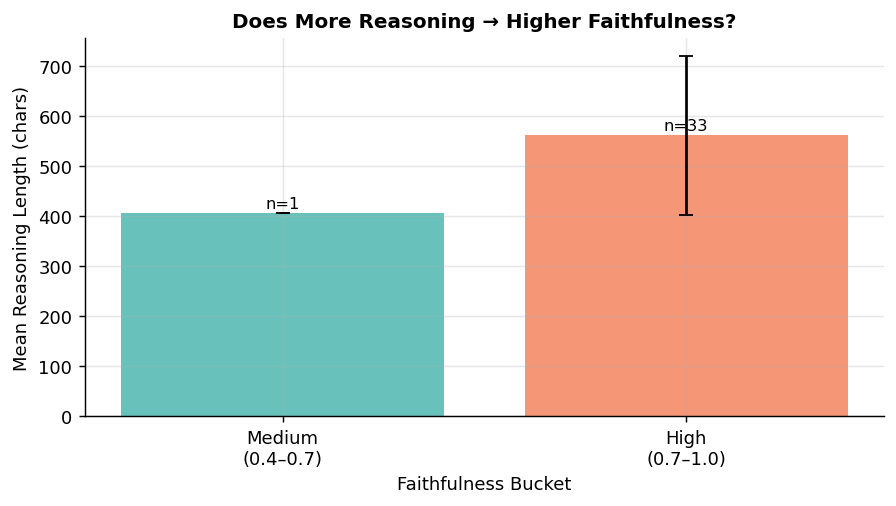

Saved → reports/cot_faithfulness_buckets.png


In [23]:
# ── Faithfulness buckets vs reasoning length ──────────────────────────────
#
# Bin faithfulness into Low / Medium / High and show how reasoning length
# differs — longer reasoning should correlate with higher faithfulness.

bins   = [0, 0.4, 0.7, 1.01]
labels_bin = ['Low\n(0–0.4)', 'Medium\n(0.4–0.7)', 'High\n(0.7–1.0)']
df['faith_bucket'] = pd.cut(df['faithfulness'], bins=bins, labels=labels_bin, right=False)

bucket_means = df.groupby('faith_bucket', observed=True)['reasoning_length'].mean()
bucket_stds  = df.groupby('faith_bucket', observed=True)['reasoning_length'].std().fillna(0)
bucket_counts= df.groupby('faith_bucket', observed=True)['reasoning_length'].count()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(bucket_means.index, bucket_means.values, color=PALETTE[:3], alpha=.85,
              yerr=bucket_stds.values, capsize=4)
for bar, cnt in zip(bars, bucket_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'n={cnt}', ha='center', fontsize=9)

ax.set_xlabel('Faithfulness Bucket')
ax.set_ylabel('Mean Reasoning Length (chars)')
ax.set_title('Does More Reasoning → Higher Faithfulness?', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/cot_faithfulness_buckets.png', bbox_inches='tight')
plt.show()
print('Saved → reports/cot_faithfulness_buckets.png')

## 5. Summary Table

In [24]:
print('\n=== OVERALL EVALUATION SUMMARY ===')
overall = df[['faithfulness', 'answer_relevancy', 'context_utilization']].agg(['mean', 'std', 'min', 'max']).round(3)
print(overall.to_string())

print('\n=== TOP 3 DOCUMENTS (by faithfulness) ===')
top3_cols = ['title', 'faithfulness_mean', 'context_utilization_mean', 'answer_relevancy_mean', 'appearances']
available = [c for c in top3_cols if c in doc_agg_filtered.columns]
print(doc_agg_filtered[available].head(3).to_string(index=False))

print('\n=== BOTTOM 3 DOCUMENTS (by faithfulness) ===')
print(doc_agg_filtered[available].tail(3).to_string(index=False))

if pearson_r is not None:
    print(f'\n=== CoT CORRELATION ===')
    print(f'Pearson  r (reasoning_length vs answer_relevancy) = {pearson_r:+.4f}')
    print(f'Spearman r (reasoning_length vs answer_relevancy) = {spearman_r:+.4f}')
    interpretation = 'positive' if pearson_r > 0.1 else ('negative' if pearson_r < -0.1 else 'negligible')
    print(f'Interpretation: {interpretation} correlation')


=== OVERALL EVALUATION SUMMARY ===
      faithfulness  answer_relevancy  context_utilization
mean         0.923             0.709                0.882
std          0.113             0.145                0.122
min          0.500             0.442                0.500
max          1.000             0.999                1.000

=== TOP 3 DOCUMENTS (by faithfulness) ===
                                                title  faithfulness_mean  context_utilization_mean  answer_relevancy_mean  appearances
Conjunctivitis (Pinkeye) In Kids | Nemours KidsHealth                1.0                  0.851389               0.593329           15
                       Norovirus | Nemours KidsHealth                1.0                  0.860417               0.927977            6
               Measles (Rubeola) | Nemours KidsHealth                1.0                  0.802222               0.676090            5

=== BOTTOM 3 DOCUMENTS (by faithfulness) ===
                         title  faithfulness_